In [1]:
import cajal.sample_swc
import cajal.swc


In [2]:
#dist matrix with only metadata SWCs
cajal.sample_swc.compute_icdm_all_euclidean(
    infolder = "/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_onlymetadata_swc",
    out_csv="../data/processed/onlymetadata_withaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    preprocess=cajal.swc.preprocessor_eu(
        structure_ids=[1,2,3,4],
        soma_component_only=False),
    n_sample=100,
    num_processes=8)  # num_processes can be set to the number of cores on your machine


100%|████████████████████████████████████████████████████████████████████████████████▊| 324/325 [04:56<00:00,  1.09it/s]


[]

In [3]:
import cajal.run_gw

cajal.run_gw.compute_gw_distance_matrix(
    "../data/processed/onlymetadata_withaxons_gouwen_patch_seq_100pts_euclidean_icdm.csv",
    "../data/processed/onlymetadata_withaxons_gouwen_patchseq_100pts_euclidean_GW_dmat.csv",
    num_processes=8)


  0%|          | 0/52650 [00:00<?, ?it/s]

(array([[  0.        ,  23.40749708, 111.97206712, ...,  58.4061788 ,
          20.87870809,  91.29587899],
        [ 23.40749708,   0.        , 109.36741929, ...,  57.6747181 ,
          24.01655891,  87.82566997],
        [111.97206712, 109.36741929,   0.        , ...,  65.32454201,
         110.7436546 ,  60.93642894],
        ...,
        [ 58.4061788 ,  57.6747181 ,  65.32454201, ...,   0.        ,
          57.13551576,  47.86603751],
        [ 20.87870809,  24.01655891, 110.7436546 , ...,  57.13551576,
           0.        ,  87.90096183],
        [ 91.29587899,  87.82566997,  60.93642894, ...,  47.86603751,
          87.90096183,   0.        ]]),
 None)

In [4]:
import plotly.io as pio
pio.renderers.default = 'iframe'

import cajal.utilities
import umap
import plotly.express

# Read GW distance matrix
cells, gw_dist_dict = cajal.utilities.read_gw_dists("../data/processed/onlymetadata_withaxons_gouwen_patchseq_100pts_euclidean_GW_dmat.csv", header=True)
gw_dist = cajal.utilities.dist_mat_of_dict(gw_dist_dict)

# Compute UMAP representation
reducer = umap.UMAP(metric="precomputed", random_state=1)
embedding = reducer.fit_transform(gw_dist)

# Visualize UMAP
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells])

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1857: UserWarning:

using precomputed metric; inverse_transform will be unavailable

/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/umap/umap_.py:1943: UserWarning:

n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [5]:
clusters = cajal.utilities.leiden_clustering(gw_dist, seed=1)
plotly.express.scatter(x=embedding[:,0],
                       y=embedding[:,1],
                       template="simple_white",
                       hover_name=[m + ".swc" for m in cells],
                       color = [str(m) for m in clusters])

In [20]:
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]
#why only 474 out of 538 have subclass labels?
#cells_without_suffix = [specimen_id.replace('_transformed', '').strip() for specimen_id in cells if specimen_id in metadata.index]
   
import pandas
metadata = pandas.read_csv("/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

#Visualize the UMAP
plotly.express.scatter(
        x=embedding[:, 0],
        y=embedding[:, 1],
        template="simple_white",
        hover_name= [m + ".swc" for m in cells_without_suffix],
        color=metadata["T type sub-class"], title = "T-Type Subclasses")

In [21]:
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]
#why only 474 out of 538 have subclass labels?
#cells_without_suffix = [specimen_id.replace('_transformed', '').strip() for specimen_id in cells if specimen_id in metadata.index]
   
import pandas
metadata = pandas.read_csv("/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

#Visualize the UMAP
plotly.express.scatter(
        x=embedding[:, 0],
        y=embedding[:, 1],
        template="simple_white",
        hover_name= [m + ".swc" for m in cells_without_suffix],
        color=metadata["T type"], title = "T-Type")

In [6]:
cells_without_suffix = [specimen_id.replace('_transformed', '') for specimen_id in cells]
#why only 474 out of 538 have subclass labels?
#cells_without_suffix = [specimen_id.replace('_transformed', '').strip() for specimen_id in cells if specimen_id in metadata.index]
   
import pandas
metadata = pandas.read_csv("/home/njay/cajal/Data/NewGouwen_pathseq_data/NewGouwen_metadata.csv")
metadata.index = [str(m) for m in metadata["Specimen ID"]]
metadata = metadata.loc[cells_without_suffix]

#Visualize the UMAP
plotly.express.scatter(
        x=embedding[:, 0],
        y=embedding[:, 1],
        template="simple_white",
        hover_name= [m + ".swc" for m in cells_without_suffix],
        color=metadata["Axon Pct Above Basal Dendrite"], title = "Axon Pct Above Basal Dendrite")

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy

cell_type = numpy.array(metadata["T type sub-class"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


0.4707692307692308

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy
cell_type = numpy.array(metadata["T type"])

clf = RandomForestClassifier(n_estimators=100, random_state=1)
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=gw_dist, y=cell_type, cv=cv)

numpy.mean(accuracy)


/home/njay/miniconda3/envs/morphoL/lib/python3.9/site-packages/sklearn/model_selection/_split.py:737: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=5.



0.08923076923076924

0.4861538461538462


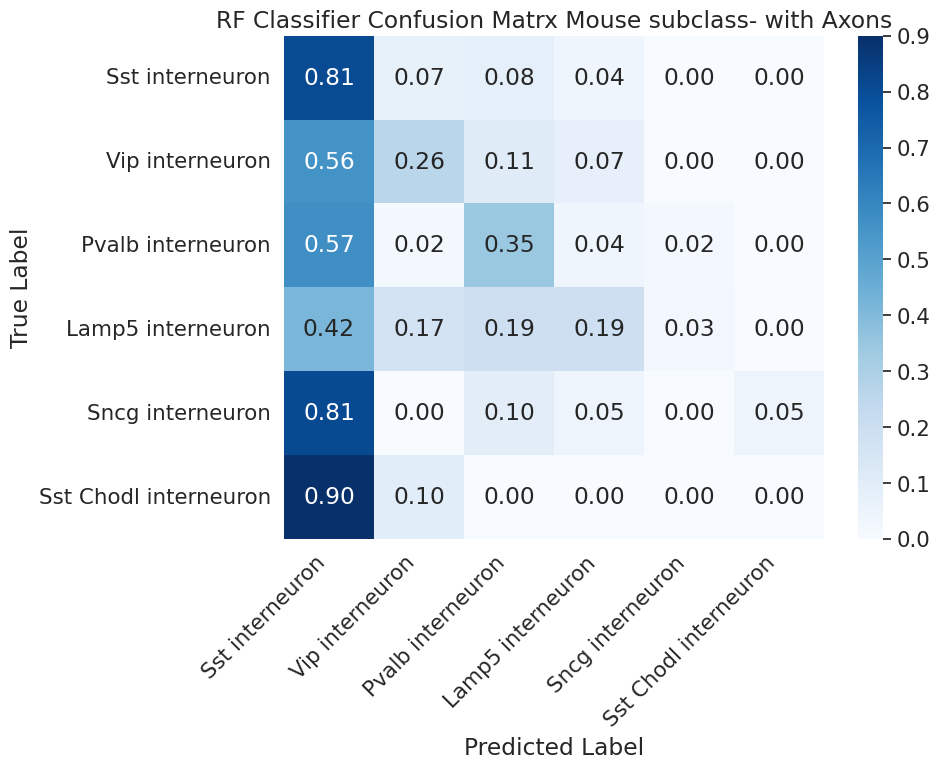

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
cell_type = np.array(metadata["T type sub-class"])

# Count the occurrences of each class
class_counts = pd.Series(cell_type).value_counts()

# Filter classes with at least 5 occurrences
selected_classes = class_counts[class_counts >= 5].index
class_indices = metadata["T type sub-class"].isin(selected_classes)
filtered_metadata = metadata[class_indices]
filtered_gw_dist = gw_dist[class_indices, :]

# Create a RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=0)
# Use StratifiedKFold for cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True)
accuracy = cross_val_score(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)
mean_accuracy = np.mean(accuracy)
print(mean_accuracy)

predictions = cross_val_predict(clf, X=filtered_gw_dist, y=cell_type[class_indices], cv=cv)

# Create a confusion matrix
conf_mat = confusion_matrix(cell_type[class_indices], predictions, labels=selected_classes)
conf_mat_percentage = conf_mat / conf_mat.sum(axis=1)[:, np.newaxis]
conf_mat_df = pd.DataFrame(conf_mat_percentage, index=selected_classes, columns=selected_classes)
plt.figure(figsize=(10, 8))
sns. set(font_scale=1.4)
sns.heatmap(conf_mat_df, annot=True
            , cmap="Blues", fmt=".2f")
plt.title("RF Classifier Confusion Matrx Mouse subclass- with Axons")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.savefig("RF Classifier Confusion Matrx Mouse subclass- with Axons")
plt.show()
